<a href="https://colab.research.google.com/github/sahmedshereen-prog/Project_Manger_Consultant/blob/main/NTI_Final__Project_NTI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/telco_prep.csv")

print("Original dataset shape:", df.shape)
print("\nFirst five rows:")
display(df.head())

Original dataset shape: (7032, 26)

First five rows:


,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,PromptInput,CustomerFeedback,feedback_length,sentiment
0,0,7590-vhveg,female,0,yes,no,1,no,no phone service,dsl,...,month-to-month,yes,electronic check,29.85,29.85,0,write a realistic customer feedback based on t...,i have been using the dsl internet service fro...,401,0.129545
1,1,5575-gnvde,male,0,no,no,34,yes,no,dsl,...,one year,no,mailed check,56.95,1889.50,0,write a realistic customer feedback based on t...,i have been a customer with this company for o...,399,0.170833
2,2,3668-qpybk,male,0,no,no,2,yes,no,dsl,...,month-to-month,yes,mailed check,53.85,108.15,1,write a realistic customer feedback based on t...,i recently signed up for dsl internet service ...,482,-0.228571
3,3,7795-cfocw,male,0,no,no,45,no,no phone service,dsl,...,one year,no,bank transfer (automatic),42.30,1840.75,0,write a realistic customer feedback based on t...,i have been a loyal customer with this company...,406,0.215801
4,4,9237-hqitu,female,0,no,no,2,yes,no,fiber optic,...,month-to-month,yes,electronic check,70.70,151.65,1,write a realistic customer feedback based on t...,i recently switched to this fiber optic intern...,418,0.030000


In [ ]:
clean_df = df.copy()

In [ ]:
clean_df.columns = clean_df.columns.str.strip()

In [ ]:
columns_to_remove = [
    "Unnamed: 0",
    "PromptInput",
    "CustomerFeedback",
    "feedback_length",
    "sentiment"
]

clean_df = clean_df.drop(
    columns=columns_to_remove,
    errors="ignore"
)

print("\nColumns after removing unnecessary fields:")
print(clean_df.columns.tolist())


Columns after removing unnecessary fields:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
clean_df["customerID"] = (
    clean_df["customerID"]
    .astype(str)
    .str.strip()
    .str.upper()
)

In [ ]:
categorical_columns = clean_df.select_dtypes(
    include=["object"]
).columns.tolist()

categorical_columns.remove("customerID")

for column in categorical_columns:
    clean_df[column] = (
        clean_df[column]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
    )

In [ ]:
numerical_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn"
]

for column in numerical_columns:
    clean_df[column] = pd.to_numeric(
        clean_df[column],
        errors="coerce"
    )

In [ ]:
print("\nMissing values before handling:")
print(clean_df.isnull().sum())

numeric_missing_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for column in numeric_missing_columns:
    clean_df[column] = clean_df[column].fillna(
        clean_df[column].median()
    )

for column in categorical_columns:
    if clean_df[column].isnull().sum() > 0:
        clean_df[column] = clean_df[column].fillna(
            clean_df[column].mode()[0]
        )

clean_df = clean_df.dropna(
    subset=["customerID", "SeniorCitizen", "Churn"]
)


Missing values before handling:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
duplicates_before = clean_df.duplicated().sum()

clean_df = clean_df.drop_duplicates()

print("\nExact duplicate rows removed:", duplicates_before)


Exact duplicate rows removed: 0


In [ ]:
duplicate_ids_before = clean_df["customerID"].duplicated().sum()

clean_df = clean_df.drop_duplicates(
    subset=["customerID"],
    keep="first"
)

print("Duplicate customer IDs removed:", duplicate_ids_before)

Duplicate customer IDs removed: 0


In [ ]:
binary_columns = [
    "SeniorCitizen",
    "Churn"
]

for column in binary_columns:
    print(f"\nUnique values in {column}:")
    print(clean_df[column].unique())

clean_df = clean_df[
    clean_df["SeniorCitizen"].isin([0, 1])
]

clean_df = clean_df[
    clean_df["Churn"].isin([0, 1])
]


Unique values in SeniorCitizen:
[0 1]

Unique values in Churn:
[0 1]


In [ ]:
clean_df = clean_df[
    clean_df["tenure"].between(0, 72)
]

clean_df = clean_df[
    clean_df["MonthlyCharges"] >= 0
]

clean_df = clean_df[
    clean_df["TotalCharges"] >= 0
]

In [ ]:
clean_df["SeniorCitizen"] = clean_df["SeniorCitizen"].astype("int8")
clean_df["tenure"] = clean_df["tenure"].astype("int16")
clean_df["Churn"] = clean_df["Churn"].astype("int8")

In [ ]:
final_columns = [
    "customerID",
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges",
    "Churn"
]

In [ ]:
clean_df = clean_df.reset_index(drop=True)

In [ ]:
print("\n" + "=" * 60)
print("FINAL DATA QUALITY REPORT")
print("=" * 60)

print("\nFinal dataset shape:")
print(clean_df.shape)

print("\nMissing values:")
print(clean_df.isnull().sum())

print("\nTotal missing values:")
print(clean_df.isnull().sum().sum())

print("\nExact duplicate rows:")
print(clean_df.duplicated().sum())

print("\nDuplicate customer IDs:")
print(clean_df["customerID"].duplicated().sum())

print("\nUnique customers:")
print(clean_df["customerID"].nunique())

print("\nData types:")
print(clean_df.dtypes)

print("\nChurn distribution:")
print(clean_df["Churn"].value_counts())

print("\nChurn percentages:")
print(
    clean_df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nNumerical summary:")
display(
    clean_df[
        [
            "SeniorCitizen",
            "tenure",
            "MonthlyCharges",
            "TotalCharges",
            "Churn"
        ]
    ].describe()
)

print("\nCleaned dataset preview:")
display(clean_df.head())


FINAL DATA QUALITY REPORT

Final dataset shape:
(7032, 21)

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing values:
0

Exact duplicate rows:
0

Duplicate customer IDs:
0

Unique customers:
7032

Data types:
customerID           object
gender               object
SeniorCitizen          int8
Partner              object
Dependents           object
tenure                int16
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     objec

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785
std,0.368844,24.545260,30.085974,2266.771362,0.441782
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000



Cleaned dataset preview:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,female,0,yes,no,1,no,no phone service,dsl,no,...,no,no,no,no,month-to-month,yes,electronic check,29.85,29.85,0
1,5575-GNVDE,male,0,no,no,34,yes,no,dsl,yes,...,yes,no,no,no,one year,no,mailed check,56.95,1889.50,0
2,3668-QPYBK,male,0,no,no,2,yes,no,dsl,yes,...,no,no,no,no,month-to-month,yes,mailed check,53.85,108.15,1
3,7795-CFOCW,male,0,no,no,45,no,no phone service,dsl,yes,...,yes,yes,no,no,one year,no,bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,female,0,no,no,2,yes,no,fiber optic,no,...,no,no,no,no,month-to-month,yes,electronic check,70.70,151.65,1


In [ ]:
clean_df.to_csv(
    "telco_prep_cleaned.csv",
    index=False
)

print("\nCleaning completed successfully.")
print("Saved as: telco_prep_cleaned.csv")


Cleaning completed successfully.
Saved as: telco_prep_cleaned.csv


(7032, 25)
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


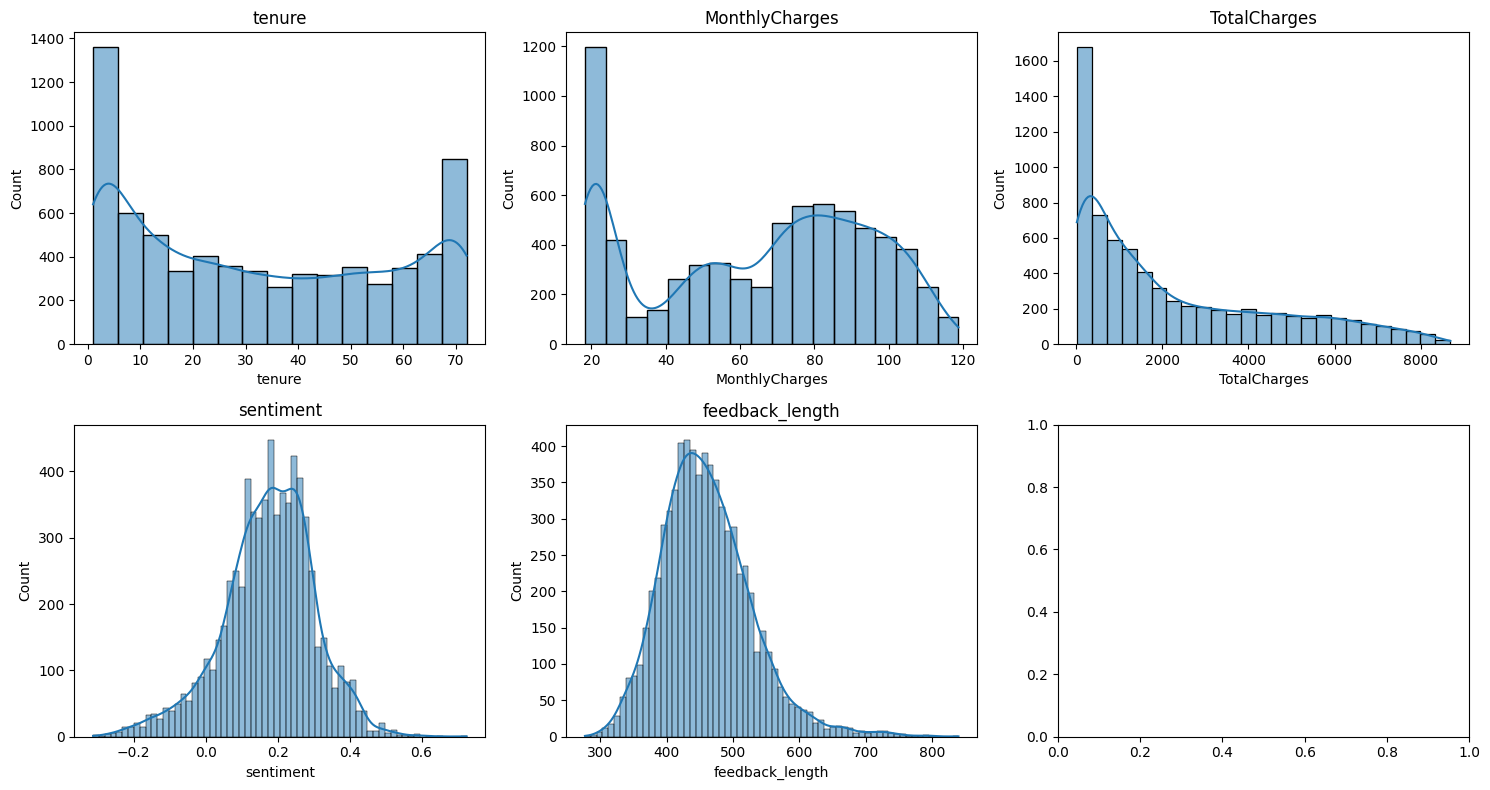

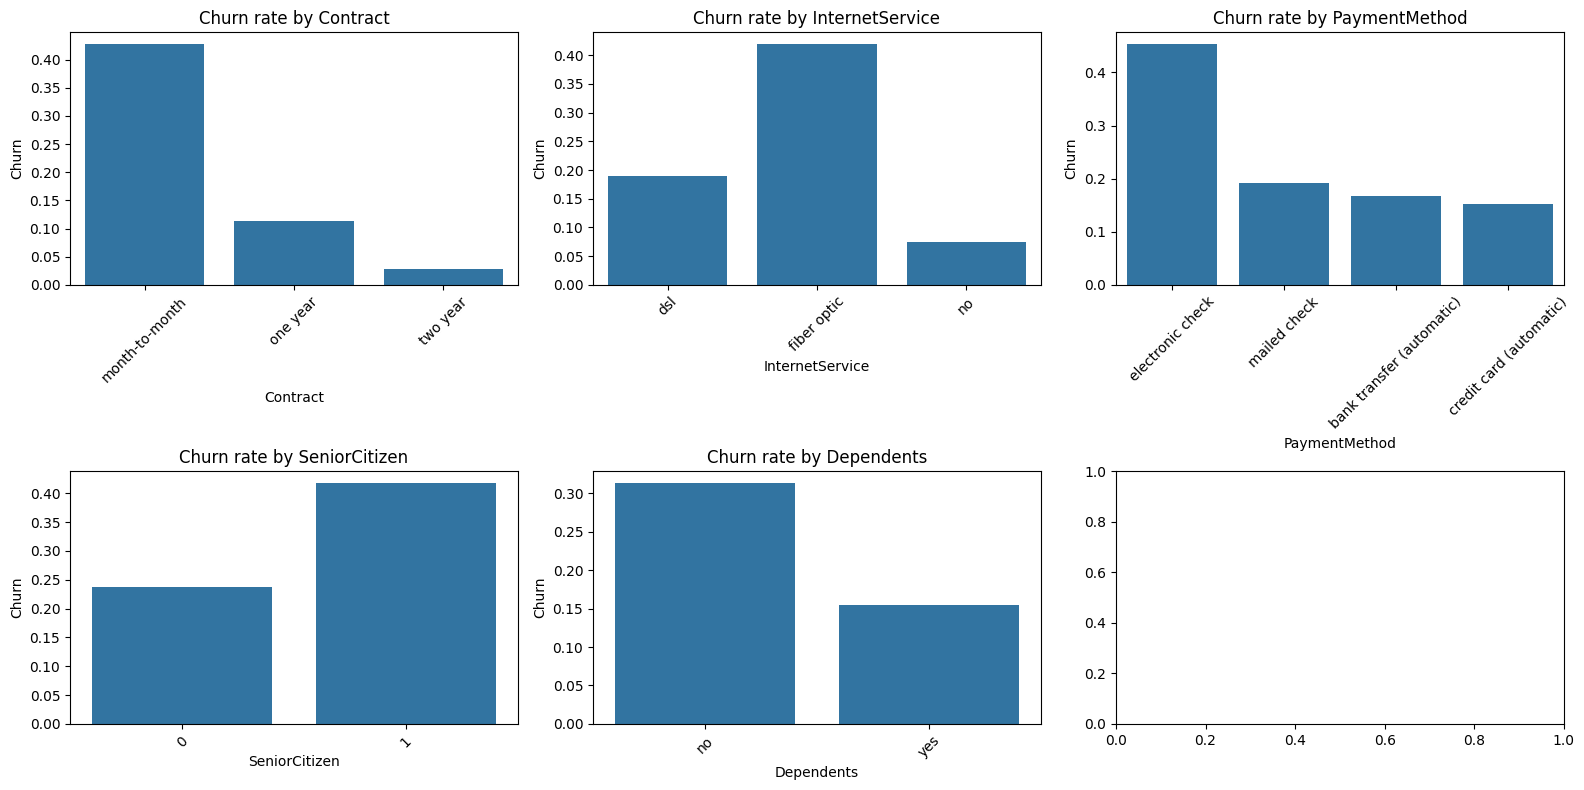

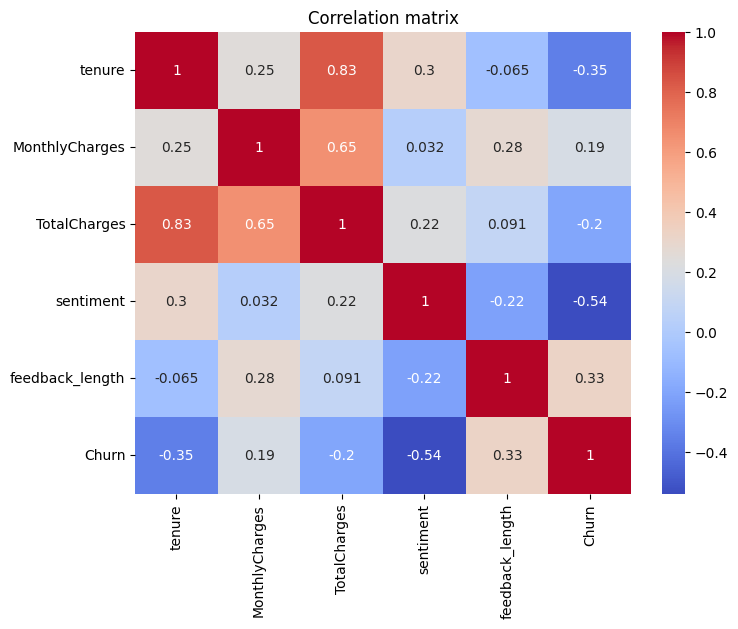

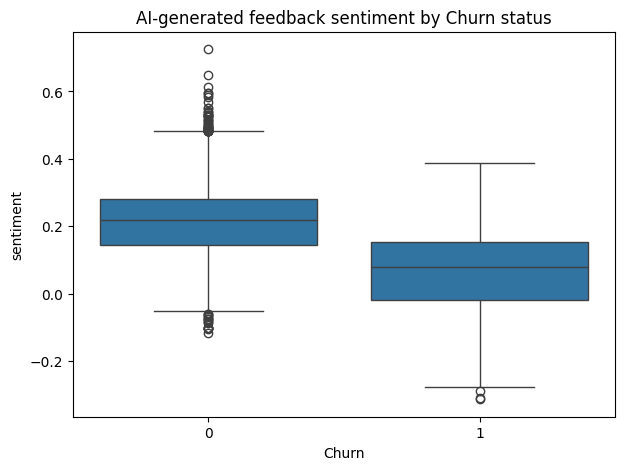

        count      mean       std       min       25%       50%       75%  \
Churn                                                                       
0      5163.0  0.216940  0.102432 -0.115625  0.146023  0.218333  0.280625   
1      1869.0  0.060838  0.121675 -0.312500 -0.018182  0.078125  0.153571   

          max  
Churn          
0      0.7250  
1      0.3875  


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('telco_prep.csv', index_col=0)

print(df.shape)
print(df['Churn'].value_counts(normalize=True))

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'sentiment', 'feedback_length']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen', 'Dependents']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    sns.barplot(data=df, x=col, y='Churn', ax=ax, errorbar=None)
    ax.set_title(f'Churn rate by {col}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols + ['Churn']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Churn', y='sentiment')
plt.title('AI-generated feedback sentiment by Churn status')
plt.show()

print(df.groupby('Churn')['sentiment'].describe())

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

df_fe = df.copy()

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df_fe[col] = df_fe[col].map({'yes': 1, 'no': 0})

df_fe['is_month_to_month'] = (df_fe['Contract'] == 'month-to-month').astype(int)
df_fe['is_fiber_optic'] = (df_fe['InternetService'] == 'fiber optic').astype(int)
df_fe['is_electronic_check'] = (df_fe['PaymentMethod'] == 'electronic check').astype(int)
df_fe['avg_monthly_spend'] = df_fe['TotalCharges'] / (df_fe['tenure'] + 1)

cat_cols = ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
            'StreamingMovies', 'Contract', 'PaymentMethod']
df_fe = pd.get_dummies(df_fe, columns=cat_cols, drop_first=True)

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'sentiment',
                 'feedback_length', 'avg_monthly_spend']

df_fe = df_fe.drop(columns=['PromptInput', 'CustomerFeedback', 'customerID'])

print(df_fe.shape)
df_fe.head()

(7032, 37)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,feedback_length,...,TechSupport_yes,StreamingTV_no internet service,StreamingTV_yes,StreamingMovies_no internet service,StreamingMovies_yes,Contract_one year,Contract_two year,PaymentMethod_credit card (automatic),PaymentMethod_electronic check,PaymentMethod_mailed check
0,0,1,0,1,0,1,29.85,29.85,0,401,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,399,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,482,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,0,42.30,1840.75,0,406,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,2,1,1,70.70,151.65,1,418,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_fe, test_size=0.3, stratify=df_fe['Churn'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['Churn'], random_state=42
)

scaler = StandardScaler()
train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])
val_df[numeric_cols] = scaler.transform(val_df[numeric_cols])
test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])

train_df.to_csv('telco_train.csv', index=False)
val_df.to_csv('telco_val.csv', index=False)
test_df.to_csv('telco_test.csv', index=False)

print(train_df.shape, val_df.shape, test_df.shape)

(4922, 37) (1055, 37) (1055, 37)


In [ ]:
import pandas as pd
import numpy as np
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("telco_prep_cleaned.csv")
print("Shape of cleaned data:", df.shape)

Shape of cleaned data: (7032, 21)


In [ ]:
service_cols = [
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]

In [ ]:
not_subscribed = {"no", "no phone service", "no internet service"}
df["total_services"] = df[service_cols].apply(
    lambda row: sum(str(v).strip().lower() not in not_subscribed for v in row),
    axis=1,
)

In [ ]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12", "12-24", "24-48", "48-72"],
    include_lowest=True,
).astype(str)

In [ ]:
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

In [ ]:
numerical_columns = X.select_dtypes(include="number").columns.tolist()
categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("\nNumerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)


Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'total_services']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                categorical_columns),
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

In [ ]:
print("\n" + "=" * 55)
print("FEATURE ENGINEERING COMPLETED")
print("=" * 55)
print("Columns before encoding:", X.shape[1])
print("Columns after encoding :", X_train_df.shape[1])
print("Train set:", X_train_df.shape, " Test set:", X_test_df.shape)
print("Missing values after processing:", X_train_df.isnull().sum().sum())
print("\nFirst 3 processed rows:")
print(X_train_df.head(3).to_string())


FEATURE ENGINEERING COMPLETED
Columns before encoding: 21
Columns after encoding : 50
Train set: (5625, 50)  Test set: (1407, 50)
Missing values after processing: 0

First 3 processed rows:
      num__SeniorCitizen  num__tenure  num__MonthlyCharges  num__TotalCharges  num__total_services  cat__gender_female  cat__gender_male  cat__Partner_no  cat__Partner_yes  cat__Dependents_no  cat__Dependents_yes  cat__PhoneService_no  cat__PhoneService_yes  cat__MultipleLines_no  cat__MultipleLines_no phone service  cat__MultipleLines_yes  cat__InternetService_dsl  cat__InternetService_fiber optic  cat__InternetService_no  cat__OnlineSecurity_no  cat__OnlineSecurity_no internet service  cat__OnlineSecurity_yes  cat__OnlineBackup_no  cat__OnlineBackup_no internet service  cat__OnlineBackup_yes  cat__DeviceProtection_no  cat__DeviceProtection_no internet service  cat__DeviceProtection_yes  cat__TechSupport_no  cat__TechSupport_no internet service  cat__TechSupport_yes  cat__StreamingTV_no  cat__Stre

In [ ]:
joblib.dump(preprocessor, "preprocessor.pkl")
print("\nSaved: preprocessor.pkl")


Saved: preprocessor.pkl


In [ ]:
df.shape

(7032, 23)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
cluster_features = ["tenure", "MonthlyCharges", "TotalCharges", "total_services"]
X_cluster = df[cluster_features].copy()

cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

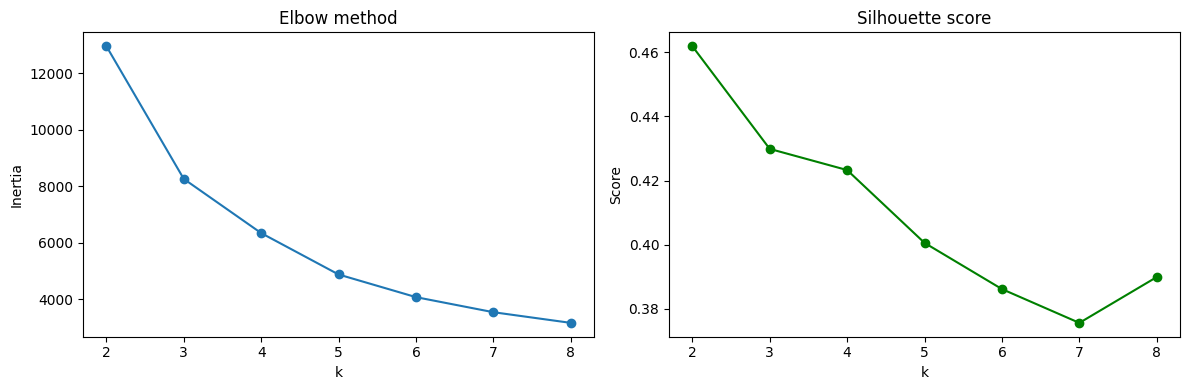

In [ ]:
inertia, silhouette, k_range = [], [], range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_cluster_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(k_range), inertia, "o-")
ax1.set_title("Elbow method"); ax1.set_xlabel("k"); ax1.set_ylabel("Inertia")
ax2.plot(list(k_range), silhouette, "o-", color="green")
ax2.set_title("Silhouette score"); ax2.set_xlabel("k"); ax2.set_ylabel("Score")
plt.tight_layout(); plt.show()

In [ ]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_cluster_scaled)

Customer segments (archetypes):
         size  avg_tenure  avg_monthly  avg_total  avg_services  churn_%
cluster                                                                 
0         990       54.07        30.04    1613.48          2.09      4.0
1        2327       17.30        78.95    1343.58          4.58     44.0
2        1992       59.36        92.03    5452.75          6.73     15.0
3        1723        9.26        34.18     273.04          1.75     29.0


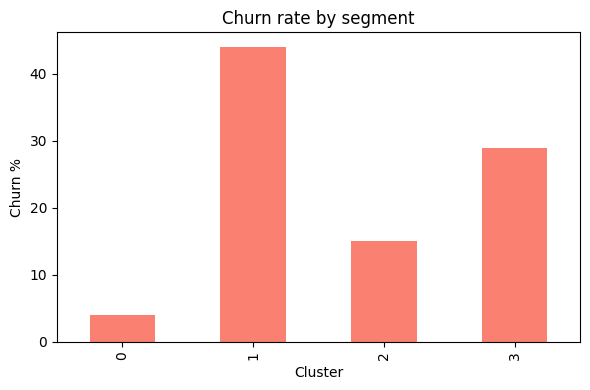

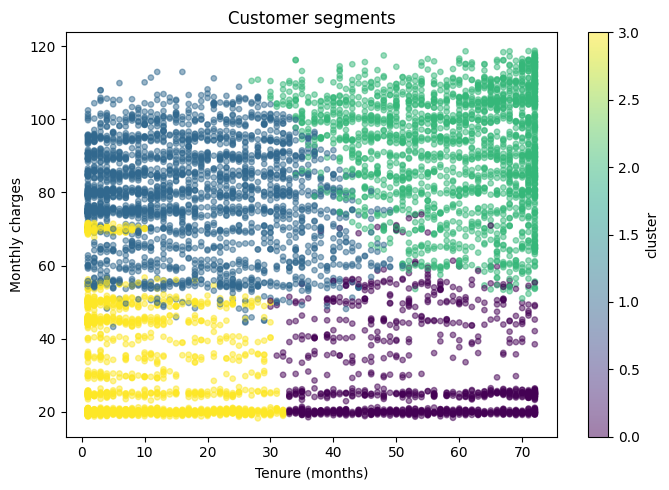

In [ ]:
profile = df.groupby("cluster").agg(
    size=("cluster", "size"),
    avg_tenure=("tenure", "mean"),
    avg_monthly=("MonthlyCharges", "mean"),
    avg_total=("TotalCharges", "mean"),
    avg_services=("total_services", "mean"),
    churn_rate=("Churn", "mean"),
).round(2)
profile["churn_%"] = (profile["churn_rate"] * 100).round(1)
profile = profile.drop(columns="churn_rate")

print("Customer segments (archetypes):")
print(profile.to_string())

plt.figure(figsize=(6, 4))
profile["churn_%"].plot(kind="bar", color="salmon")
plt.title("Churn rate by segment"); plt.ylabel("Churn %"); plt.xlabel("Cluster")
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(df["tenure"], df["MonthlyCharges"], c=df["cluster"], cmap="viridis", alpha=0.5, s=15)
plt.xlabel("Tenure (months)"); plt.ylabel("Monthly charges")
plt.title("Customer segments"); plt.colorbar(label="cluster")
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
}

results, trained = [], {}
for name, model in models.items():
    model.fit(X_train_df, y_train)
    trained[name] = model
    preds = model.predict(X_test_df)
    proba = model.predict_proba(X_test_df)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })

results_df = pd.DataFrame(results).round(3)
print("Model comparison:")
print(results_df.to_string(index=False))

best = results_df.sort_values("F1", ascending=False).iloc[0]["Model"]
print(f"\nBest model by F1: {best}\n")
print("Confusion matrix:")
print(confusion_matrix(y_test, trained[best].predict(X_test_df)))
print("\nClassification report:")
print(classification_report(y_test, trained[best].predict(X_test_df)))

Model comparison:
              Model  Accuracy  Precision  Recall    F1  ROC-AUC
Logistic Regression     0.747      0.515   0.818 0.632    0.850
      Random Forest     0.782      0.620   0.463 0.530    0.824

Best model by F1: Logistic Regression

Confusion matrix:
[[745 288]
 [ 68 306]]

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1033
           1       0.52      0.82      0.63       374

    accuracy                           0.75      1407
   macro avg       0.72      0.77      0.72      1407
weighted avg       0.81      0.75      0.76      1407



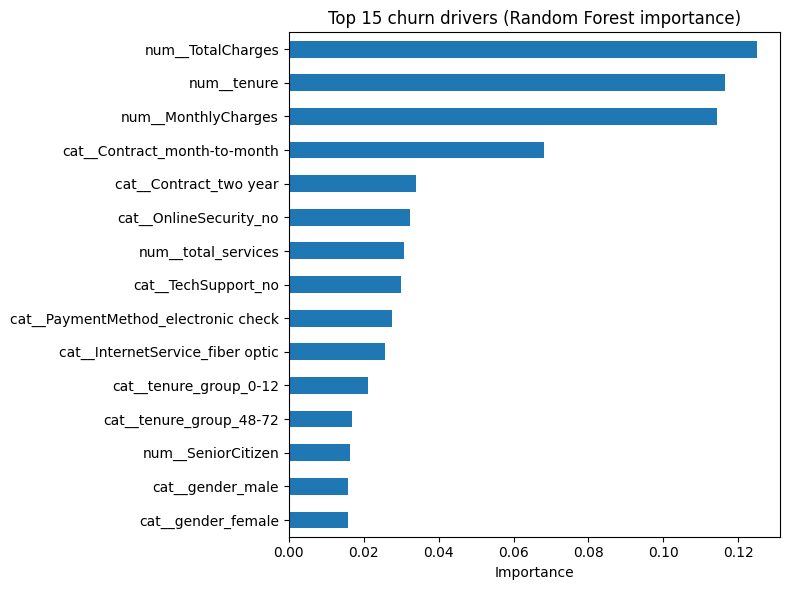

Top 15 features by Random Forest importance:
num__TotalCharges                      0.1249
num__tenure                            0.1164
num__MonthlyCharges                    0.1142
cat__Contract_month-to-month           0.0682
cat__Contract_two year                 0.0339
cat__OnlineSecurity_no                 0.0323
num__total_services                    0.0308
cat__TechSupport_no                    0.0299
cat__PaymentMethod_electronic check    0.0276
cat__InternetService_fiber optic       0.0257
cat__tenure_group_0-12                 0.0212
cat__tenure_group_48-72                0.0170
num__SeniorCitizen                     0.0162
cat__gender_male                       0.0159
cat__gender_female                     0.0158

Factors that most INCREASE churn risk (positive coefficients):
cat__StreamingMovies_yes               0.188
cat__PaymentMethod_electronic check    0.216
cat__OnlineSecurity_no                 0.221
num__total_services                    0.288
cat__tenure_group_48-

In [ ]:
feature_names = X_train_df.columns

rf = trained["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

top = importances.head(15)
plt.figure(figsize=(8, 6))
top.iloc[::-1].plot(kind="barh")
plt.title("Top 15 churn drivers (Random Forest importance)")
plt.xlabel("Importance"); plt.tight_layout(); plt.show()

print("Top 15 features by Random Forest importance:")
print(top.round(4).to_string())

logreg = trained["Logistic Regression"]
coefs = pd.Series(logreg.coef_[0], index=feature_names).sort_values()

print("\nFactors that most INCREASE churn risk (positive coefficients):")
print(coefs.tail(8).round(3).to_string())

print("\nFactors that most REDUCE churn risk (negative coefficients):")
print(coefs.head(8).round(3).to_string())

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
df = pd.read_csv("/content/telco_prep.csv")
clean_df = df.copy()

In [ ]:
clean_df.columns = clean_df.columns.str.strip()

In [ ]:
columns_to_remove = [
    "Unnamed: 0",
    "PromptInput",
    "CustomerFeedback",
    "feedback_length",
    "sentiment"
]
clean_df = clean_df.drop(columns=columns_to_remove, errors="ignore")

In [ ]:
clean_df["customerID"] = (
    clean_df["customerID"].astype(str).str.strip().str.upper()
)

In [ ]:
categorical_columns = clean_df.select_dtypes(include=["object"]).columns.tolist()
categorical_columns.remove("customerID")

for column in categorical_columns:
    clean_df[column] = (
        clean_df[column].astype(str).str.strip().str.lower()
        .str.replace(r"\s+", " ", regex=True)
    )

In [ ]:
numerical_columns = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
for column in numerical_columns:
    clean_df[column] = pd.to_numeric(clean_df[column], errors="coerce")

In [ ]:
numeric_missing_columns = ["tenure", "MonthlyCharges", "TotalCharges"]
for column in numeric_missing_columns:
    clean_df[column] = clean_df[column].fillna(clean_df[column].median())

for column in categorical_columns:
    if clean_df[column].isnull().sum() > 0:
        clean_df[column] = clean_df[column].fillna(clean_df[column].mode()[0])

clean_df = clean_df.dropna(subset=["customerID", "SeniorCitizen", "Churn"])

In [ ]:
clean_df = clean_df.drop_duplicates()
clean_df = clean_df.drop_duplicates(subset=["customerID"], keep="first")

In [ ]:
clean_df = clean_df[clean_df["SeniorCitizen"].isin([0, 1])]
clean_df = clean_df[clean_df["Churn"].isin([0, 1])]
clean_df = clean_df[clean_df["tenure"].between(0, 72)]
clean_df = clean_df[clean_df["MonthlyCharges"] >= 0]
clean_df = clean_df[clean_df["TotalCharges"] >= 0]

In [ ]:
clean_df["SeniorCitizen"] = clean_df["SeniorCitizen"].astype("int8")
clean_df["tenure"] = clean_df["tenure"].astype("int16")
clean_df["Churn"] = clean_df["Churn"].astype("int8")

In [ ]:
clean_df = clean_df.reset_index(drop=True)

assert "sentiment" not in clean_df.columns
assert "feedback_length" not in clean_df.columns
print("Cleaned shape:", clean_df.shape)

df = clean_df

Cleaned shape: (7032, 21)


In [ ]:
df_fe = df.copy()

binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_cols:
    df_fe[col] = df_fe[col].map({"yes": 1, "no": 0})

df_fe["is_month_to_month"] = (df_fe["Contract"] == "month-to-month").astype(int)
df_fe["is_fiber_optic"] = (df_fe["InternetService"] == "fiber optic").astype(int)
df_fe["is_electronic_check"] = (df_fe["PaymentMethod"] == "electronic check").astype(int)
df_fe["avg_monthly_spend"] = df_fe["TotalCharges"] / (df_fe["tenure"] + 1)

cat_cols = ["gender", "MultipleLines", "InternetService", "OnlineSecurity",
            "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV",
            "StreamingMovies", "Contract", "PaymentMethod"]
df_fe = pd.get_dummies(df_fe, columns=cat_cols, drop_first=True)

df_fe = df_fe.drop(columns=["customerID"], errors="ignore")

assert "sentiment" not in df_fe.columns
assert "feedback_length" not in df_fe.columns

print(df_fe.shape)

X = df_fe.drop(columns=["Churn"])
y = df_fe["Churn"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "avg_monthly_spend"]

scaler = StandardScaler()
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train = X_train.values.astype("float32")
X_val = X_val.values.astype("float32")
X_test = X_test.values.astype("float32")
y_train = y_train.values.astype("float32")
y_val = y_val.values.astype("float32")
y_test = y_test.values.astype("float32")

print(X_train.shape, X_val.shape, X_test.shape)

(7032, 35)
(4781, 34) (844, 34) (1407, 34)


In [ ]:
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.681054131054131), 1: np.float64(1.8808025177025964)}


In [ ]:
keras.backend.clear_session()

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc"),
             keras.metrics.Precision(name="precision"),
             keras.metrics.Recall(name="recall")]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=10, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6980 - auc: 0.7847 - loss: 0.5621 - precision: 0.4590 - recall: 0.7616 - val_accuracy: 0.7536 - val_auc: 0.8399 - val_loss: 0.4911 - val_precision: 0.5229 - val_recall: 0.8170
Epoch 2/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7381 - auc: 0.8233 - loss: 0.5153 - precision: 0.5048 - recall: 0.7931 - val_accuracy: 0.7630 - val_auc: 0.8516 - val_loss: 0.5019 - val_precision: 0.5341 - val_recall: 0.8393
Epoch 3/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7344 - auc: 0.8280 - loss: 0.5090 - precision: 0.5002 - recall: 0.8017 - val_accuracy: 0.7654 - val_auc: 0.8533 - val_loss: 0.4849 - val_precision: 0.5378 - val_recall: 0.8259
Epoch 4/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7385 - auc: 0.8353 - loss: 0.4987 - precision: 0.5052 - recall: 0.8033 - val_accuracy: 0.7464 - val_auc: 0.8521 - val_loss: 0.5041 - val_precision: 0.5136 - val_recall: 0.8438
Epoch 5/100
150/150 ━━━━━━━━

In [ ]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.4 MB/s eta 0:00:00


In [ ]:
test_results = model.evaluate(X_test, y_test, verbose=0)
print(dict(zip(model.metrics_names, test_results)))

import keras_tuner as kt

def build_model(hp):
    keras.backend.clear_session()
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))

    num_layers = hp.Int("num_layers", 1, 3)
    for i in range(num_layers):
        units = hp.Choice(f"units_{i}", [16, 32, 64, 128])
        model.add(layers.Dense(units, activation="relu"))
        dropout = hp.Float(f"dropout_{i}", 0.0, 0.5, step=0.1)
        model.add(layers.Dropout(dropout))

    model.add(layers.Dense(1, activation="sigmoid"))

    lr = hp.Choice("lr", [0.01, 0.001, 0.0005])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc")]
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective("val_auc", direction="max"),
    max_trials=3,
    directory="tuner_results",
    project_name="telco_churn_ann_v2",
    overwrite=True
)

tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5)],
    verbose=1
)

best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:", best_hp.values)

best_test_results = best_model.evaluate(X_test, y_test, verbose=0)
print(dict(zip(best_model.metrics_names, best_test_results)))

Trial 3 Complete [00h 00m 08s]
val_auc: 0.8586405515670776

Best val_auc So Far: 0.8586405515670776
Total elapsed time: 00h 01m 19s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Best hyperparameters: {'num_layers': 1, 'units_0': 64, 'dropout_0': 0.2, 'lr': 0.01, 'units_1': 32, 'dropout_1': 0.0, 'units_2': 16, 'dropout_2': 0.0}
{'loss': 0.5340226888656616, 'compile_metrics': 0.8511021137237549}


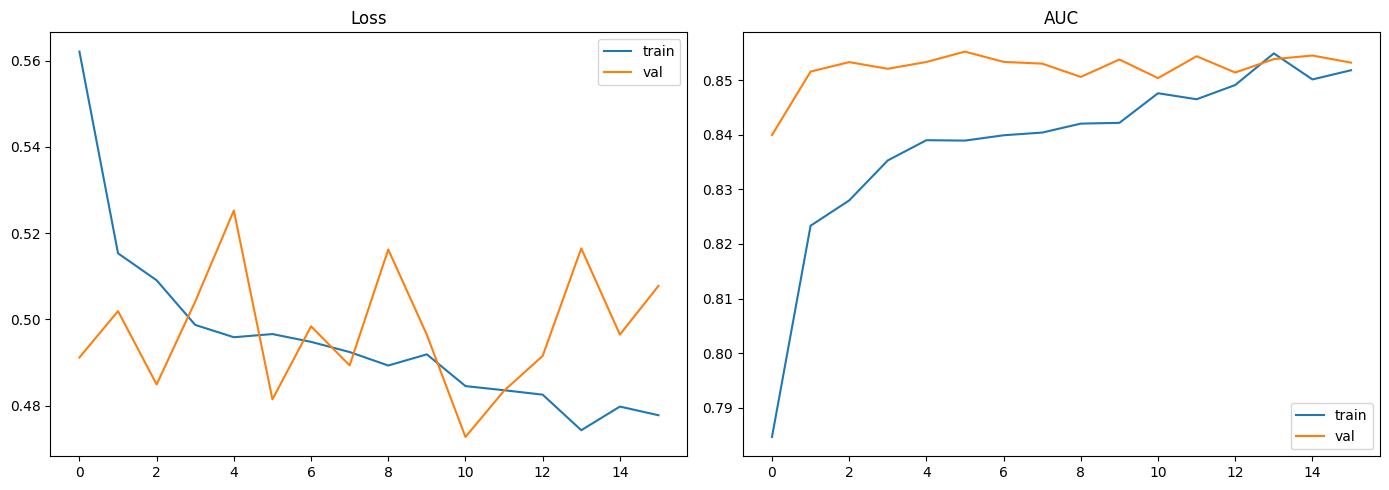

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history.history["auc"], label="train")
axes[1].plot(history.history["val_auc"], label="val")
axes[1].set_title("AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


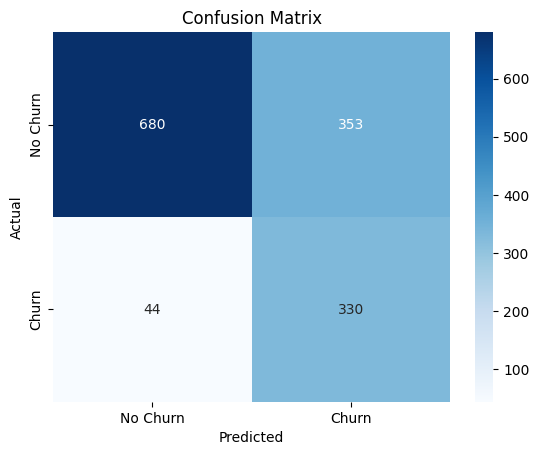

              precision    recall  f1-score   support

    No Churn       0.94      0.66      0.77      1033
       Churn       0.48      0.88      0.62       374

    accuracy                           0.72      1407
   macro avg       0.71      0.77      0.70      1407
weighted avg       0.82      0.72      0.73      1407



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_proba = best_model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Model comparison:
              Model  Accuracy  Precision  Recall    F1  ROC-AUC
Logistic Regression     0.747      0.515   0.818 0.632    0.850
      Random Forest     0.782      0.620   0.463 0.530    0.824
        ANN (tuned)     0.718      0.483   0.882 0.624    0.851


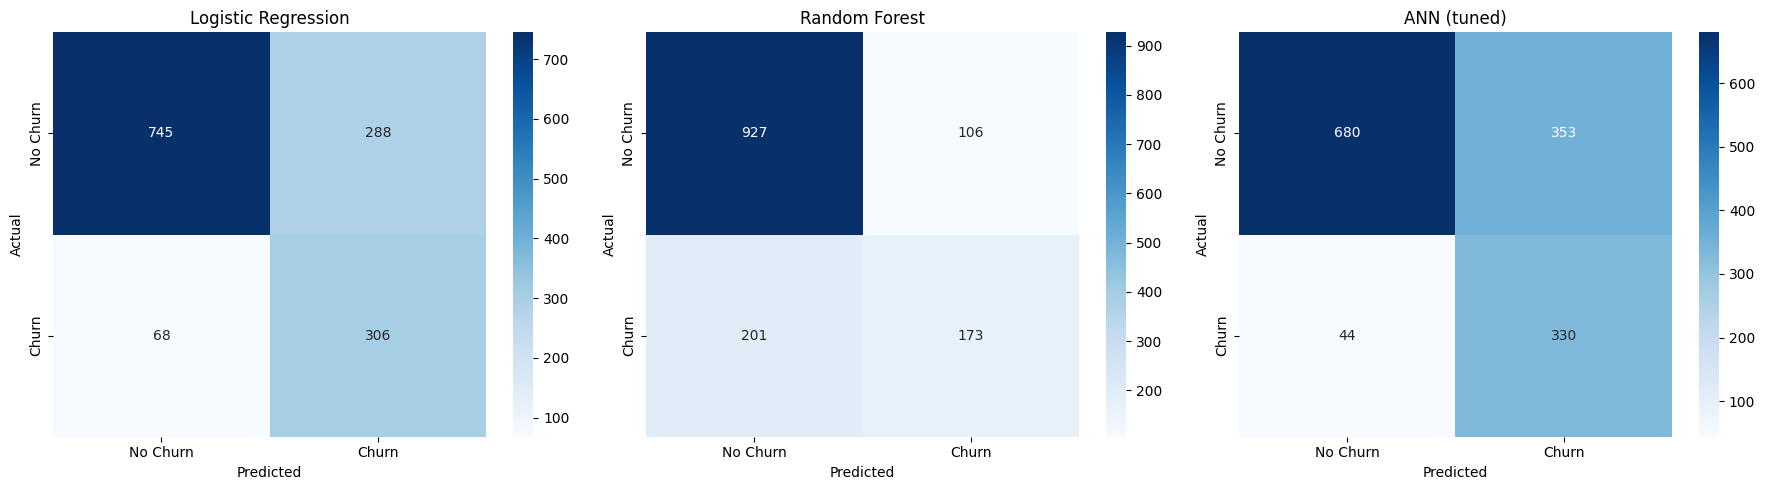

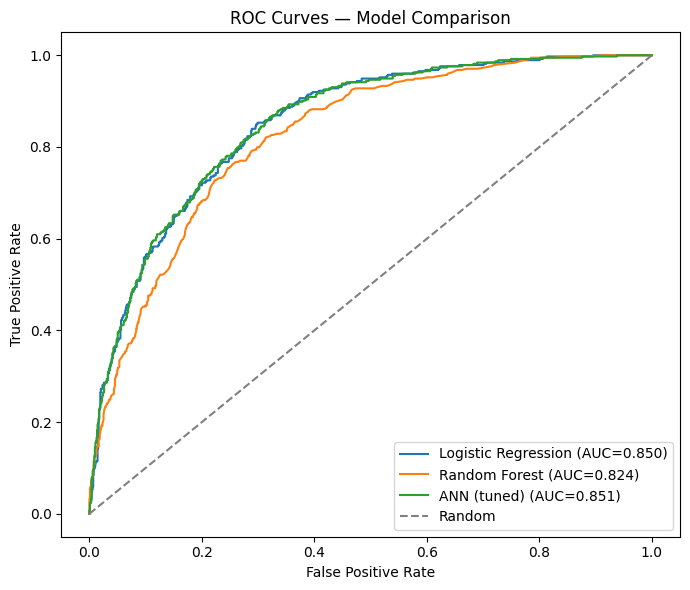

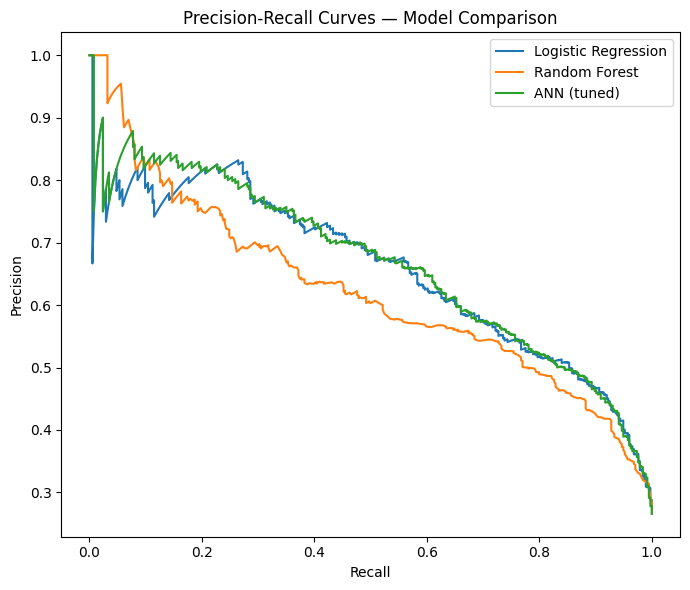


Best model by F1: Logistic Regression

              precision    recall  f1-score   support

    No Churn       0.92      0.72      0.81      1033
       Churn       0.52      0.82      0.63       374

    accuracy                           0.75      1407
   macro avg       0.72      0.77      0.72      1407
weighted avg       0.81      0.75      0.76      1407



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

model_predictions = {}

for name, clf in trained.items():
    preds = clf.predict(X_test_df)
    proba = clf.predict_proba(X_test_df)[:, 1]
    model_predictions[name] = {
        "y_true": y_test,
        "preds": preds,
        "proba": proba
    }

ann_proba = best_model.predict(X_test).ravel()
ann_preds = (ann_proba > 0.5).astype(int)
model_predictions["ANN (tuned)"] = {
    "y_true": y_test,
    "preds": ann_preds,
    "proba": ann_proba
}

rows = []
for name, res in model_predictions.items():
    y_true = res["y_true"]
    preds = res["preds"]
    proba = res["proba"]
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds),
        "Recall": recall_score(y_true, preds),
        "F1": f1_score(y_true, preds),
        "ROC-AUC": roc_auc_score(y_true, proba)
    })

comparison_df = pd.DataFrame(rows).round(3)
print("Model comparison:")
print(comparison_df.to_string(index=False))

n_models = len(model_predictions)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, model_predictions.items()):
    cm = confusion_matrix(res["y_true"], res["preds"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))
for name, res in model_predictions.items():
    fpr, tpr, _ = roc_curve(res["y_true"], res["proba"])
    auc_val = roc_auc_score(res["y_true"], res["proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()

from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(7, 6))
for name, res in model_predictions.items():
    prec, rec, _ = precision_recall_curve(res["y_true"], res["proba"])
    plt.plot(rec, prec, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()

best_name = comparison_df.sort_values("F1", ascending=False).iloc[0]["Model"]
best_res = model_predictions[best_name]
print(f"\nBest model by F1: {best_name}\n")
print(classification_report(best_res["y_true"], best_res["preds"],
                             target_names=["No Churn", "Churn"]))

In [ ]:
print("Model comparison:")
print(comparison_df.to_string(index=False))

Model comparison:
              Model  Accuracy  Precision  Recall    F1  ROC-AUC
Logistic Regression     0.747      0.515   0.818 0.632    0.850
      Random Forest     0.782      0.620   0.463 0.530    0.824
        ANN (tuned)     0.718      0.483   0.882 0.624    0.851


In [ ]:
import joblib

metric_to_use = "F1"

best_row = comparison_df.sort_values(metric_to_use, ascending=False).iloc[0]
best_model_name = best_row["Model"]
print(f"Winning model by {metric_to_use}: {best_model_name}")
print(best_row)

if best_model_name == "ANN (tuned)":
    best_model.save("final_model.keras")
    print("Saved ANN as final_model.keras")
else:
    joblib.dump(trained[best_model_name], "final_model.pkl")
    print(f"Saved {best_model_name} as final_model.pkl")

Winning model by F1: Logistic Regression
Model        Logistic Regression
Accuracy                   0.747
Precision                  0.515
Recall                     0.818
F1                         0.632
ROC-AUC                     0.85
Name: 0, dtype: object
Saved Logistic Regression as final_model.pkl


In [ ]:
print("Model comparison:")
print(comparison_df.to_string(index=False))

Model comparison:
              Model  Accuracy  Precision  Recall    F1  ROC-AUC
Logistic Regression     0.747      0.515   0.818 0.632    0.850
      Random Forest     0.782      0.620   0.463 0.530    0.824
        ANN (tuned)     0.718      0.483   0.882 0.624    0.851


In [ ]:
# ============================================================
# TELCO CUSTOMER CHURN PREDICTION UI - GOOGLE COLAB
# Run your notebook model-training cells first, then run this.
# ============================================================

!pip install -q gradio

import gradio as gr
import pandas as pd
import numpy as np


# ============================================================
# 1. CHECK THAT THE REQUIRED MODELS EXIST
# ============================================================

required_objects = [
    "preprocessor",
    "trained",
    "kmeans",
    "cluster_scaler"
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing_objects:
    raise ValueError(
        "Run all preprocessing, clustering and model-training cells first.\n"
        f"Missing objects: {missing_objects}"
    )


# ============================================================
# 2. SELECT THE BEST SKLEARN MODEL
# ============================================================

if "results_df" in globals():
    best_model_name = (
        results_df
        .sort_values("F1", ascending=False)
        .iloc[0]["Model"]
    )
else:
    best_model_name = "Random Forest"

selected_model = trained[best_model_name]

print("Model used by the UI:", best_model_name)


# ============================================================
# 3. CLUSTER NAMES AND RECOMMENDATIONS
# ============================================================

def create_cluster_descriptions():

    descriptions = {}

    if "profile" not in globals():
        return {
            0: "Customer Segment 1",
            1: "Customer Segment 2",
            2: "Customer Segment 3",
            3: "Customer Segment 4"
        }

    profile_copy = profile.copy()

    highest_churn_cluster = profile_copy["churn_%"].idxmax()
    lowest_churn_cluster = profile_copy["churn_%"].idxmin()
    highest_value_cluster = profile_copy["avg_total"].idxmax()
    newest_cluster = profile_copy["avg_tenure"].idxmin()

    for cluster_id in profile_copy.index:

        if cluster_id == highest_churn_cluster:
            descriptions[cluster_id] = "High-Risk Customers"

        elif cluster_id == lowest_churn_cluster:
            descriptions[cluster_id] = "Loyal Customers"

        elif cluster_id == highest_value_cluster:
            descriptions[cluster_id] = "High-Value Customers"

        elif cluster_id == newest_cluster:
            descriptions[cluster_id] = "New Customers"

        else:
            descriptions[cluster_id] = "Regular Customers"

    return descriptions


cluster_descriptions = create_cluster_descriptions()


# ============================================================
# 4. HELPER FUNCTIONS
# ============================================================

def normalise_text(value):
    return str(value).strip().lower()


def calculate_total_services(
    phone_service,
    multiple_lines,
    internet_service,
    online_security,
    online_backup,
    device_protection,
    tech_support,
    streaming_tv,
    streaming_movies
):

    service_values = [
        phone_service,
        multiple_lines,
        internet_service,
        online_security,
        online_backup,
        device_protection,
        tech_support,
        streaming_tv,
        streaming_movies
    ]

    not_subscribed = {
        "no",
        "no phone service",
        "no internet service"
    }

    total = sum(
        normalise_text(value) not in not_subscribed
        for value in service_values
    )

    return total


def calculate_tenure_group(tenure):

    tenure = float(tenure)

    if tenure <= 12:
        return "0-12"
    elif tenure <= 24:
        return "12-24"
    elif tenure <= 48:
        return "24-48"
    else:
        return "48-72"


def get_risk_level(probability):

    if probability < 0.30:
        return "LOW RISK", "The customer is currently unlikely to leave."

    elif probability < 0.60:
        return "MEDIUM RISK", "The customer should be monitored and engaged."

    else:
        return "HIGH RISK", "The customer needs immediate retention action."


def get_risk_drivers(
    senior_citizen,
    tenure,
    internet_service,
    online_security,
    tech_support,
    contract,
    payment_method,
    monthly_charges,
    paperless_billing
):

    drivers = []

    if contract == "month-to-month":
        drivers.append("Month-to-month contract")

    if tenure <= 12:
        drivers.append("New customer with short tenure")

    if internet_service == "fiber optic":
        drivers.append("Uses fibre-optic internet")

    if online_security == "no":
        drivers.append("Does not have online security")

    if tech_support == "no":
        drivers.append("Does not have technical support")

    if payment_method == "electronic check":
        drivers.append("Pays using electronic check")

    if monthly_charges >= 80:
        drivers.append("High monthly charges")

    if senior_citizen == 1:
        drivers.append("Senior citizen customer")

    if paperless_billing == "yes":
        drivers.append("Uses paperless billing")

    if len(drivers) == 0:
        drivers.append("No major customer risk factors detected")

    return drivers[:5]


def get_recommendations(
    risk_level,
    contract,
    online_security,
    tech_support,
    monthly_charges,
    tenure
):

    recommendations = []

    if risk_level == "HIGH RISK":
        recommendations.append(
            "Contact the customer through the retention team."
        )

    if contract == "month-to-month":
        recommendations.append(
            "Offer a discounted one-year or two-year contract."
        )

    if online_security == "no":
        recommendations.append(
            "Offer an online-security service bundle."
        )

    if tech_support == "no":
        recommendations.append(
            "Offer free or discounted technical support."
        )

    if monthly_charges >= 80:
        recommendations.append(
            "Review the customer's package and offer a lower-cost plan."
        )

    if tenure <= 12:
        recommendations.append(
            "Send onboarding support and a new-customer loyalty offer."
        )

    if len(recommendations) == 0:
        recommendations.append(
            "Maintain regular engagement and provide loyalty rewards."
        )

    return recommendations[:4]


# ============================================================
# 5. PREDICTION FUNCTION
# ============================================================

def predict_customer_churn(
    gender,
    senior_citizen,
    partner,
    dependents,
    tenure,
    phone_service,
    multiple_lines,
    internet_service,
    online_security,
    online_backup,
    device_protection,
    tech_support,
    streaming_tv,
    streaming_movies,
    contract,
    paperless_billing,
    payment_method,
    monthly_charges,
    total_charges
):

    try:

        tenure = float(tenure)
        monthly_charges = float(monthly_charges)
        total_charges = float(total_charges)
        senior_citizen = int(senior_citizen)

        if tenure < 0 or tenure > 72:
            return (
                "Invalid input",
                0,
                "Tenure must be between 0 and 72 months.",
                "Not available",
                "Correct the tenure value.",
                {}
            )

        if monthly_charges < 0 or total_charges < 0:
            return (
                "Invalid input",
                0,
                "Charges cannot be negative.",
                "Not available",
                "Correct the charge values.",
                {}
            )

        # Convert text to the same lowercase format used during training
        gender = normalise_text(gender)
        partner = normalise_text(partner)
        dependents = normalise_text(dependents)
        phone_service = normalise_text(phone_service)
        multiple_lines = normalise_text(multiple_lines)
        internet_service = normalise_text(internet_service)
        online_security = normalise_text(online_security)
        online_backup = normalise_text(online_backup)
        device_protection = normalise_text(device_protection)
        tech_support = normalise_text(tech_support)
        streaming_tv = normalise_text(streaming_tv)
        streaming_movies = normalise_text(streaming_movies)
        contract = normalise_text(contract)
        paperless_billing = normalise_text(paperless_billing)
        payment_method = normalise_text(payment_method)

        total_services = calculate_total_services(
            phone_service,
            multiple_lines,
            internet_service,
            online_security,
            online_backup,
            device_protection,
            tech_support,
            streaming_tv,
            streaming_movies
        )

        tenure_group = calculate_tenure_group(tenure)

        # Customer data in the same structure used during training
        customer_data = pd.DataFrame([{
            "gender": gender,
            "SeniorCitizen": senior_citizen,
            "Partner": partner,
            "Dependents": dependents,
            "tenure": tenure,
            "PhoneService": phone_service,
            "MultipleLines": multiple_lines,
            "InternetService": internet_service,
            "OnlineSecurity": online_security,
            "OnlineBackup": online_backup,
            "DeviceProtection": device_protection,
            "TechSupport": tech_support,
            "StreamingTV": streaming_tv,
            "StreamingMovies": streaming_movies,
            "Contract": contract,
            "PaperlessBilling": paperless_billing,
            "PaymentMethod": payment_method,
            "MonthlyCharges": monthly_charges,
            "TotalCharges": total_charges,
            "total_services": total_services,
            "tenure_group": tenure_group
        }])

        # Apply the saved preprocessing
        customer_processed = preprocessor.transform(customer_data)

        # Predict churn probability
        churn_probability = float(
            selected_model.predict_proba(customer_processed)[0][1]
        )

        churn_percentage = round(churn_probability * 100, 2)

        if churn_probability >= 0.50:
            prediction = "Customer is likely to churn"
        else:
            prediction = "Customer is likely to stay"

        risk_level, risk_explanation = get_risk_level(
            churn_probability
        )

        # Predict customer segment
        cluster_input = pd.DataFrame([{
            "tenure": tenure,
            "MonthlyCharges": monthly_charges,
            "TotalCharges": total_charges,
            "total_services": total_services
        }])

        cluster_scaled = cluster_scaler.transform(cluster_input)
        cluster_number = int(kmeans.predict(cluster_scaled)[0])

        cluster_name = cluster_descriptions.get(
            cluster_number,
            f"Customer Segment {cluster_number + 1}"
        )

        cluster_result = (
            f"{cluster_name}\n"
            f"Cluster number: {cluster_number}\n"
            f"Total subscribed services: {total_services}"
        )

        drivers = get_risk_drivers(
            senior_citizen,
            tenure,
            internet_service,
            online_security,
            tech_support,
            contract,
            payment_method,
            monthly_charges,
            paperless_billing
        )

        drivers_text = "\n".join(
            [f"• {driver}" for driver in drivers]
        )

        recommendations = get_recommendations(
            risk_level,
            contract,
            online_security,
            tech_support,
            monthly_charges,
            tenure
        )

        recommendations_text = "\n".join(
            [f"• {recommendation}" for recommendation in recommendations]
        )

        customer_summary = {
            "Prediction": prediction,
            "Churn probability": f"{churn_percentage}%",
            "Risk level": risk_level,
            "Customer segment": cluster_name,
            "Tenure": f"{tenure:.0f} months",
            "Monthly charges": f"{monthly_charges:.2f}",
            "Total charges": f"{total_charges:.2f}",
            "Subscribed services": total_services,
            "Model": best_model_name
        }

        risk_output = (
            f"{risk_level}\n\n"
            f"{risk_explanation}"
        )

        return (
            prediction,
            churn_percentage,
            risk_output,
            cluster_result,
            drivers_text,
            recommendations_text,
            customer_summary
        )

    except Exception as error:

        return (
            "Prediction error",
            0,
            str(error),
            "Not available",
            "Check that all notebook cells were run correctly.",
            "Run the preprocessing and model-training cells again.",
            {}
        )


# ============================================================
# 6. CREATE THE USER INTERFACE
# ============================================================

with gr.Blocks(
    title="Telco Customer Churn Predictor",
    theme=gr.themes.Soft()
) as app:

    gr.Markdown(
        """
        # 📱 Telco Customer Churn Prediction Dashboard

        Enter the customer's information to predict whether the customer
        is likely to leave the company.

        The dashboard also displays the customer's risk level, segment,
        important risk factors and recommended business actions.
        """
    )

    with gr.Row():

        # ---------------- INPUT SIDE ----------------
        with gr.Column():

            gr.Markdown("## 👤 Customer Information")

            with gr.Row():
                gender_input = gr.Dropdown(
                    choices=["female", "male"],
                    value="female",
                    label="Gender"
                )

                senior_input = gr.Dropdown(
                    choices=[0, 1],
                    value=0,
                    label="Senior Citizen",
                    info="0 = No, 1 = Yes"
                )

            with gr.Row():
                partner_input = gr.Dropdown(
                    choices=["yes", "no"],
                    value="no",
                    label="Has a Partner?"
                )

                dependents_input = gr.Dropdown(
                    choices=["yes", "no"],
                    value="no",
                    label="Has Dependents?"
                )

            tenure_input = gr.Slider(
                minimum=0,
                maximum=72,
                value=12,
                step=1,
                label="Tenure in Months"
            )

            gr.Markdown("## Phone and Internet Services")

            phone_input = gr.Dropdown(
                choices=["yes", "no"],
                value="yes",
                label="Phone Service"
            )

            multiple_lines_input = gr.Dropdown(
                choices=["yes", "no", "no phone service"],
                value="no",
                label="Multiple Lines"
            )

            internet_input = gr.Dropdown(
                choices=["dsl", "fiber optic", "no"],
                value="dsl",
                label="Internet Service"
            )

            with gr.Row():
                security_input = gr.Dropdown(
                    choices=["yes", "no", "no internet service"],
                    value="no",
                    label="Online Security"
                )

                backup_input = gr.Dropdown(
                    choices=["yes", "no", "no internet service"],
                    value="no",
                    label="Online Backup"
                )

            with gr.Row():
                protection_input = gr.Dropdown(
                    choices=["yes", "no", "no internet service"],
                    value="no",
                    label="Device Protection"
                )

                support_input = gr.Dropdown(
                    choices=["yes", "no", "no internet service"],
                    value="no",
                    label="Technical Support"
                )

            with gr.Row():
                tv_input = gr.Dropdown(
                    choices=["yes", "no", "no internet service"],
                    value="no",
                    label="Streaming TV"
                )

                movies_input = gr.Dropdown(
                    choices=["yes", "no", "no internet service"],
                    value="no",
                    label="Streaming Movies"
                )

            gr.Markdown("## Contract and Payment")

            contract_input = gr.Dropdown(
                choices=[
                    "month-to-month",
                    "one year",
                    "two year"
                ],
                value="month-to-month",
                label="Contract Type"
            )

            paperless_input = gr.Dropdown(
                choices=["yes", "no"],
                value="yes",
                label="Paperless Billing"
            )

            payment_input = gr.Dropdown(
                choices=[
                    "electronic check",
                    "mailed check",
                    "bank transfer (automatic)",
                    "credit card (automatic)"
                ],
                value="electronic check",
                label="Payment Method"
            )

            with gr.Row():
                monthly_input = gr.Number(
                    value=70,
                    minimum=0,
                    label="Monthly Charges"
                )

                total_input = gr.Number(
                    value=840,
                    minimum=0,
                    label="Total Charges"
                )

            predict_button = gr.Button(
                "🔍 Predict Customer Churn",
                variant="primary"
            )

            clear_button = gr.ClearButton(
                value="Clear Inputs"
            )

        # ---------------- OUTPUT SIDE ----------------
        with gr.Column():

            gr.Markdown("## 📊 Prediction Results")

            prediction_output = gr.Textbox(
                label="Customer Prediction",
                lines=2
            )

            probability_output = gr.Slider(
                minimum=0,
                maximum=100,
                value=0,
                label="Churn Probability (%)",
                interactive=False
            )

            risk_output = gr.Textbox(
                label="Risk Level",
                lines=4
            )

            cluster_output = gr.Textbox(
                label="Customer Segment",
                lines=4
            )

            drivers_output = gr.Textbox(
                label="Main Risk Factors",
                lines=7
            )

            recommendations_output = gr.Textbox(
                label="Recommended Business Actions",
                lines=7
            )

            summary_output = gr.JSON(
                label="Customer Prediction Summary"
            )

    gr.Markdown(
        """
        ---
        **Risk interpretation**

        - **Low risk:** Below 30%
        - **Medium risk:** Between 30% and 60%
        - **High risk:** 60% or higher
        """
    )

    all_inputs = [
        gender_input,
        senior_input,
        partner_input,
        dependents_input,
        tenure_input,
        phone_input,
        multiple_lines_input,
        internet_input,
        security_input,
        backup_input,
        protection_input,
        support_input,
        tv_input,
        movies_input,
        contract_input,
        paperless_input,
        payment_input,
        monthly_input,
        total_input
    ]

    all_outputs = [
        prediction_output,
        probability_output,
        risk_output,
        cluster_output,
        drivers_output,
        recommendations_output,
        summary_output
    ]

    predict_button.click(
        fn=predict_customer_churn,
        inputs=all_inputs,
        outputs=all_outputs
    )

    clear_button.add(
        components=all_inputs + all_outputs
    )


# ============================================================
# 7. START THE APPLICATION
# ============================================================

app.launch(
    share=True,
    debug=True
)

Model used by the UI: Logistic Regression


/tmp/ipykernel_589/3086672447.py:491: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://aa8786d47394b0ccce.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://aa8786d47394b0ccce.gradio.live
